/tmp/ipykernel_1128/1894140252.py:94: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = 0.5 * ((input_x + 1.0) @ neurons) / dim_input
Fitting batch: 2it [00:00, 261.34it/s]              

acts_train_flat.shape=torch.Size([1000, 250]), xs_train.shape=torch.Size([1000, 1])


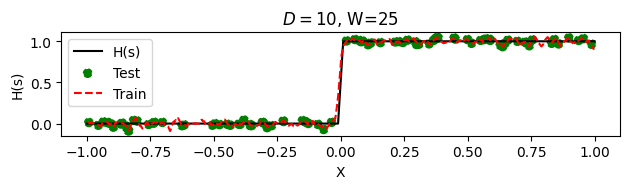

In [8]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
from nonlinear_approximator import (
    activations,
    inference,
    model,
    params,
    training, 
)
import numba
import cProfile
from scipy.stats import qmc
from sklearn.linear_model import Ridge, RidgeCV, Lasso
%matplotlib inline

# Parameters 
config1 = params.RegressionParams(
    width=2,
    depth=2,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config2 = params.RegressionParams(
    width=25,
    depth=2,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config3 = params.RegressionParams(
    width=25,
    depth=10,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

def gen_neurons(dimension, number):
    sampler = qmc.LatinHypercube(d=dimension)
    sample = sampler.random(n=number) 
    
    return sample
def rmse(x, y):
    return np.mean(np.abs(x.squeeze()-y.squeeze()))
    return np.sqrt(np.mean(np.square(x - y)))
    
@numba.jit(nopython=True)
def tent(x, mu=1.99):
    nonlinear_params = {"alpha": 900, "beta": -0.06045, "r": 3.99, "mu": 1.99}

    # return np.exp(-900 * np.square(x)) + -0.06045
    return mu * np.minimum(x, 1 - x)

def step(x):
    out = np.zeros_like(x)
    out[x > 0] = 1
    out[x == 0] = .5
    return out


def tent_torch(x, mu=1.99):
    return mu * torch.minimum(x, 1 - x)



def compute_activations_torch(neurons, input_x, depth):
    """
    neurons: (dim_input, width)
    input_x: (num_samples, dim_input)

    Returns:
        (num_samples, depth * width)
    """
    num_samples, dim_input = input_x.shape
    width = neurons.shape[1]

    # allocate final output directly
    out = torch.empty(
        (num_samples, depth * width),
        device=input_x.device,
        dtype=input_x.dtype
    )

    # ---- layer 0 ----
    x = 0.5 * ((input_x + 1.0) @ neurons) / dim_input
    out[:, 0:width] = x

    # ---- subsequent layers ----
    for l in range(1, depth):
        x = tent_torch(x)
        out[:, l*width:(l+1)*width] = x

    return out

# compute_activations_torch = torch.compile(compute_activations_torch)

@numba.jit(nopython=False,nogil=True,parallel=True)
def compute_activations(neurons, input_x, depth, width):
    num_samples, dim_input = input_x.shape

    activations = np.zeros((num_samples, depth, width))
    for idx_sample in range(num_samples):
        for idx_layer in range(depth):
            if idx_layer == 0:
                sample =  np.expand_dims(input_x[idx_sample, :], axis=-1)
                activations[idx_sample, idx_layer, :] = .5*(sample+1).T @ neurons / dim_input 
            else:
                activations[idx_sample, idx_layer, :] = tent(
                    activations[idx_sample, idx_layer - 1, :]
                )
    return activations

@numba.jit(nopython=True)        
def flatten_activations(acts: NDArray[np.floating]) -> NDArray[np.floating]:
    num_samples, depth, width = acts.shape
    flattened = np.zeros((num_samples, depth * width), dtype=np.float64)
    for idx_sample in range(num_samples):
        flattened[idx_sample, :] = np.copy(np.ravel(acts[idx_sample, :, :]))
    return flattened


xs = np.expand_dims(np.linspace(-1, 1, 100),axis=-1)
xs_train = torch.from_numpy(np.random.uniform(-1, 1, (1000,1) ).astype(np.float32)) 
xs_test = torch.from_numpy(np.random.uniform(-1, 1, (100,1) ).astype(np.float32))
plt.figure('h')
plt.clf()

for idx, config in enumerate([config3]):
    plt.subplot(3,1,idx+1)
    plt.plot(xs, step(xs), label='H(s)', c='black')

    neurons = gen_neurons(config.input_dimension, config.width).T

    # zero mean input
    # acts_train = compute_activations(
    #     neurons=neurons, input_x=xs_train, depth=config.depth, width=config.width
    # )
    acts_train_flat = compute_activations_torch(
        neurons=neurons, input_x=xs_train, depth=config.depth
    )
    # acts_test = compute_activations(
    #     neurons=neurons, input_x=xs_test, depth=config.depth, width=config.width
    # )
    acts_test_flat = compute_activations_torch(
        neurons=neurons, input_x=xs_test, depth=config.depth
    )
    # acts_train_flat = flatten_activations(acts_train)
    # acts_test_flat = flatten_activations(acts_test)
    
    
    
    dim_in = acts_train_flat.shape[1]
    dim_out = xs_test.shape[1]
    decoder = training.BlockLowRankRLS(dim_in, dim_out, delta=1e-16, max_rank=config.depth*config.width)
    decoder.fit(
        acts_train_flat, # torch.from_numpy(acts_train_flat.astype(np.float32)), 
        torch.from_numpy(step(xs_train).astype(np.float32)),
        batch_size=512
        )
    
    truth_test = step(xs_test)
    # preds = decoder.predict(torch.from_numpy(acts_test_flat.astype(np.float32))).detach().cpu().numpy() 
    # preds_fit = decoder.predict(torch.from_numpy(acts_train_flat.astype(np.float32))).detach().cpu().numpy()

    preds = decoder.predict(acts_test_flat).detach().cpu().numpy() 
    preds_fit = decoder.predict(acts_train_flat).detach().cpu().numpy()

    print(f"{acts_train_flat.shape=}, {xs_train.shape=}")
    sortidx_train = np.argsort(xs_train,axis=0)
    sortidx_test = np.argsort(xs_test, axis=0)
    
    truth_test = truth_test[sortidx_test].squeeze()
    
    err = rmse(truth_test[sortidx_test], preds[sortidx_test]) 
    plt.scatter(xs_test[sortidx_test].squeeze(), preds[sortidx_test].squeeze(), ls='--', c='g', label='Test')
    plt.plot(xs_train[sortidx_train].squeeze(), preds_fit[sortidx_train].squeeze(), ls='--', c='r', label='Train')
    plt.xlabel("X")
    plt.ylabel("H(s)")
    plt.title(f"$D={config.depth}$, W={config.width}")

plt.legend()
plt.gcf().tight_layout()
plt.ion()
plt.show()
